In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv
/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx


LOGISTIC REGRESSION PIPELINE - RETAIL LOAN DEFAULT PREDICTION

[STEP 1] LOADING DATA...
--------------------------------------------------------------------------------
✓ Loaded: 2,260,668 rows × 145 columns

Target Distribution:
  Non-Default: 1,998,982 (88.4%)
  Default: 261,686 (11.6%)

[STEP 2] FEATURE SELECTION...
--------------------------------------------------------------------------------
✓ Numeric Features: 10
✓ Categorical Features: 7

Data Split:
  Train: 1,582,467 (70.0%)
  Test: 678,201 (30.0%)

[STEP 3] BUILDING PREPROCESSING PIPELINE...
--------------------------------------------------------------------------------
✓ Engineered Features: 24 total
  Numeric: 17
  Categorical: 7

[STEP 4] TRAINING LOGISTIC REGRESSION...
--------------------------------------------------------------------------------

Logistic Regression Performance:
  AUC-ROC: 0.7212
  Accuracy: 0.6533
  Precision: 0.2011
  Recall: 0.6715
  F1-Score: 0.3096
  Brier Score: 0.2140
  Log Loss: 0.6163

Cros

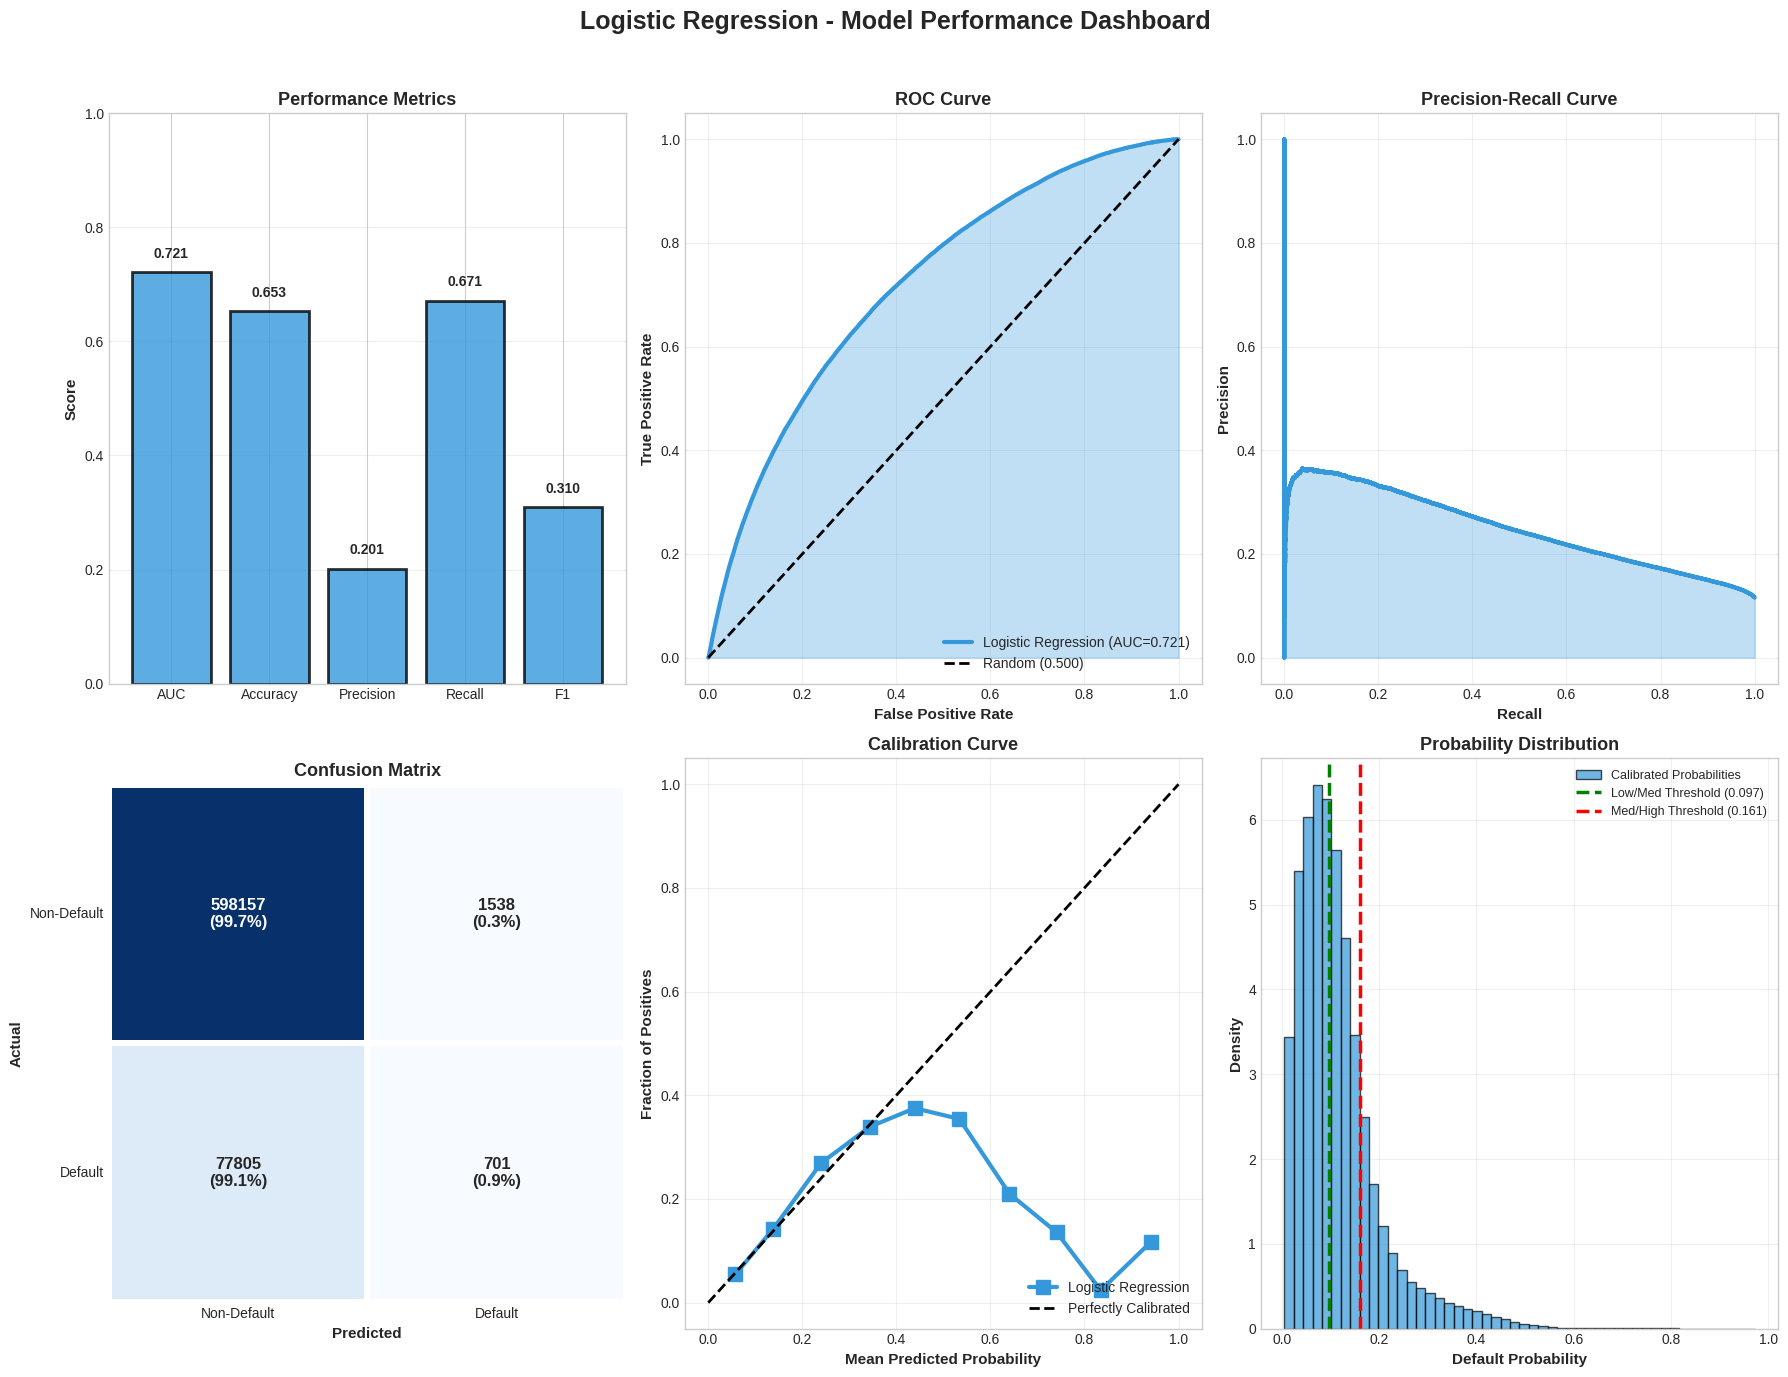

✓ Saved: lr_performance_dashboard.png


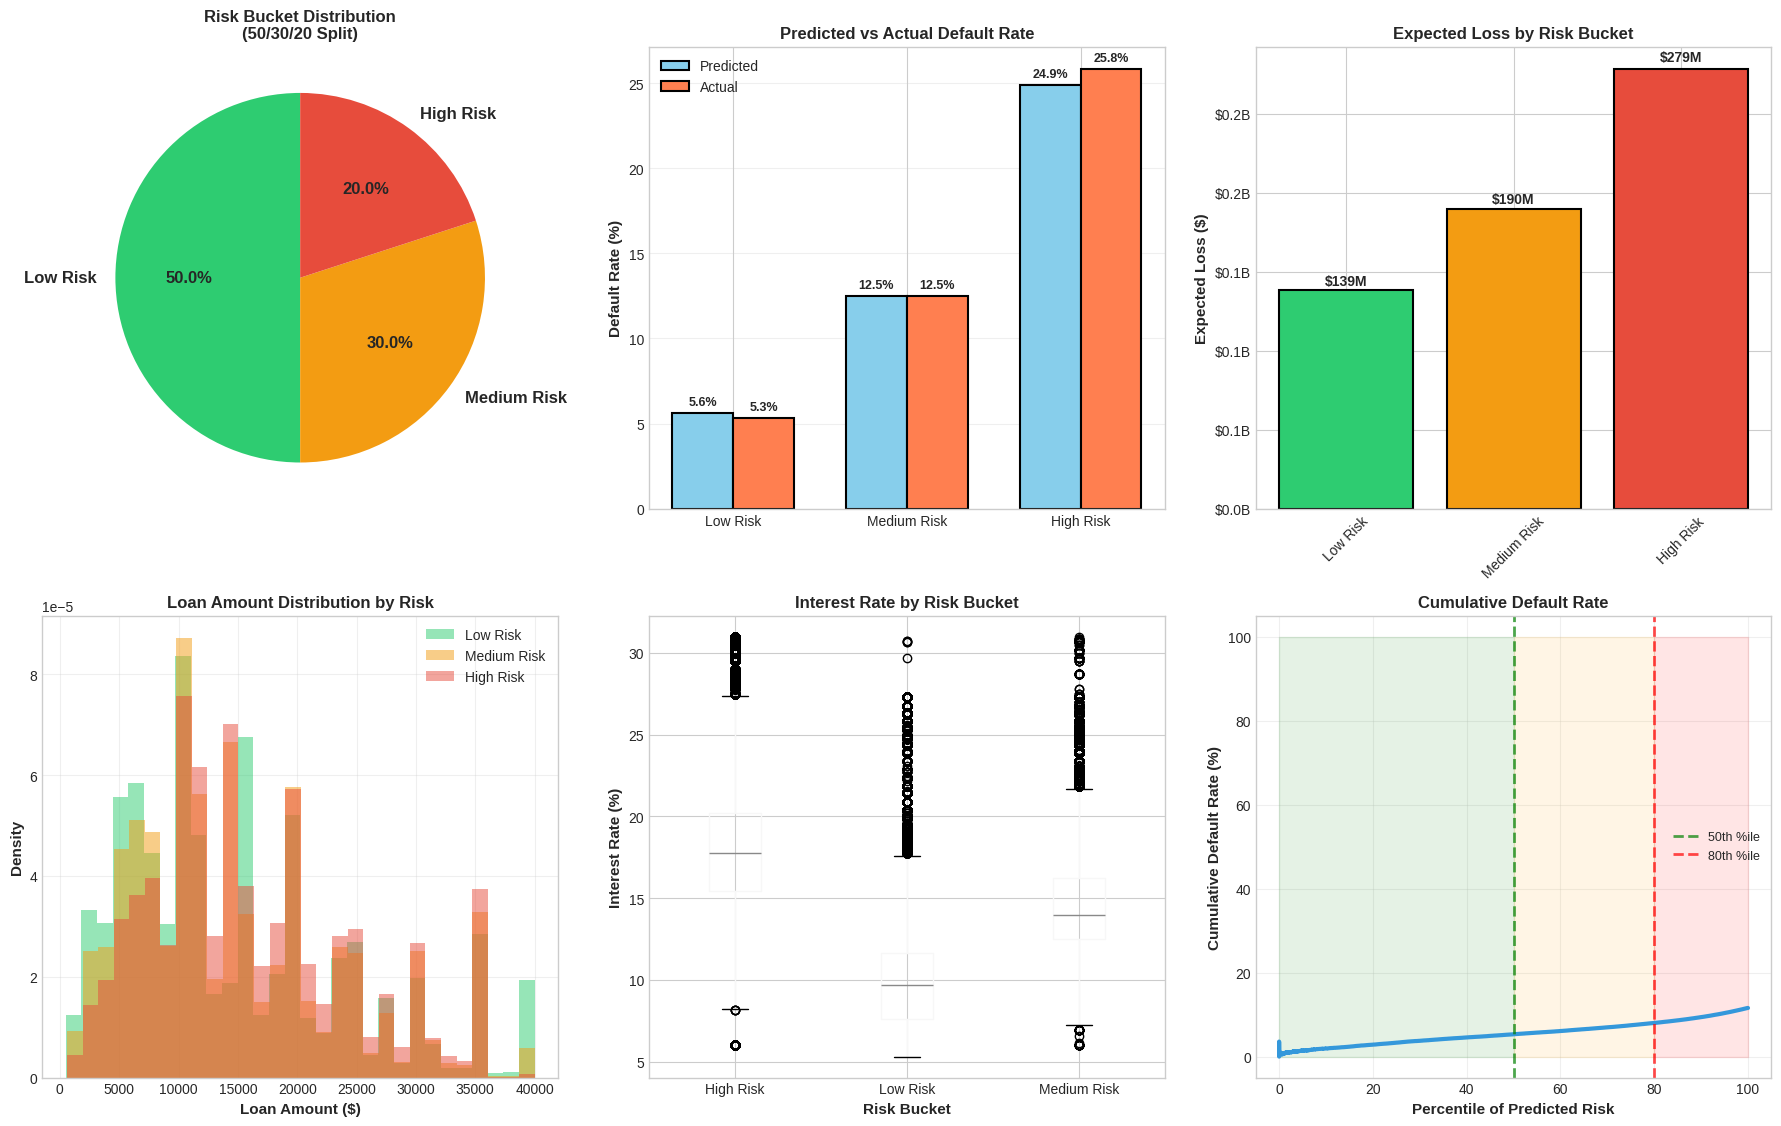

✓ Saved: lr_risk_analysis.png


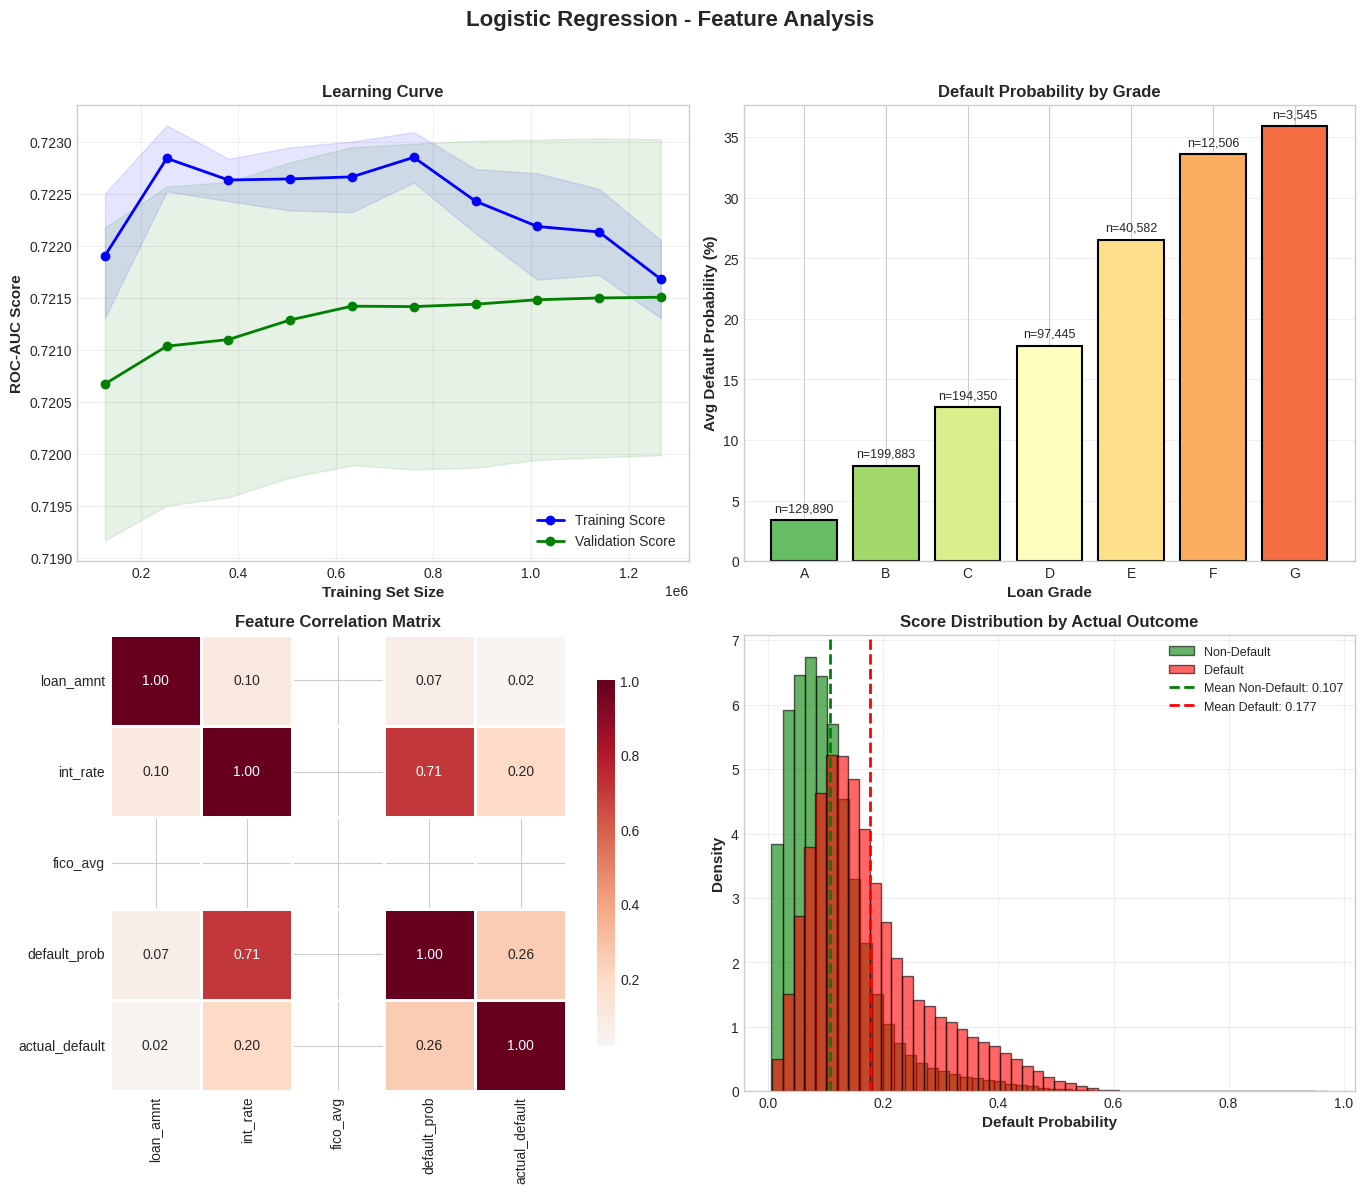

✓ Saved: lr_feature_analysis.png

[STEP 8] SAVING ARTIFACTS...
--------------------------------------------------------------------------------
✓ Saved: logistic_regression_model.pkl
✓ Saved: lr_risk_predictions.csv
✓ Saved: lr_metrics.csv
✓ Saved: lr_risk_buckets.csv

✅ LOGISTIC REGRESSION PIPELINE COMPLETE!

MODEL SUMMARY
Algorithm: Logistic Regression (L2 Regularization)
Calibration: Platt Scaling (Sigmoid)
Features: 17 numeric + 7 categorical

PERFORMANCE METRICS:
  AUC-ROC:  0.7212
  Accuracy: 0.6533
  F1-Score: 0.3096
  Precision: 0.2011
  Recall:    0.6715
  
CALIBRATION:
  Original Brier:  0.2140
  Calibrated Brier: 0.0955
  Improvement: 11.84%

RISK BUCKETS (50/30/20 Split):
  Low Risk (<0.0969):    339,101 loans
  Medium Risk (0.0969-0.1612): 203,460 loans
  High Risk (>0.1612):   135,640 loans

PORTFOLIO RISK:
  Total Exposure: $10,213,253,500.00
  Expected Loss: $607,199,656.23
  EL Rate: 5.9452%

OUTPUTS:
  - logistic_regression_model.pkl
  - lr_risk_predictions.csv
  - lr

In [7]:
# ============================================================
# RETAIL LOAN DEFAULT PREDICTION - LOGISTIC REGRESSION PIPELINE
# Quantitative Finance Hackathon 2025
# Team: Brijesh Dabhi (23110067), Siddhartha Nayak (23110311)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, 
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve, brier_score_loss,
                             classification_report, log_loss)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("LOGISTIC REGRESSION PIPELINE - RETAIL LOAN DEFAULT PREDICTION")
print("="*80)

# ============================================================
# CONFIGURATION
# ============================================================

class Config:
    RANDOM_STATE = 42
    TEST_SIZE = 0.3
    N_JOBS = -1
    LGD = 0.50  # Loss Given Default
    # Risk bucket percentiles (50/30/20 split) Dr
    LOW_RISK_PERCENTILE = 50
    MEDIUM_RISK_PERCENTILE = 80

CONFIG = Config()

# ============================================================
# CUSTOM TRANSFORMERS
# ============================================================

class OutlierClipper(BaseEstimator, TransformerMixin):
    """Clip outliers using IQR method"""
    def __init__(self, factor=1.5):
        self.factor = factor
        self.bounds_ = {}
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.bounds_[col] = {
                'lower': Q1 - self.factor * IQR,
                'upper': Q3 + self.factor * IQR
            }
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X)
        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.bounds_[col]['lower'],
                upper=self.bounds_[col]['upper']
            )
        return X.values

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Create derived features for credit risk"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Financial ratios
        X['income_to_loan_ratio'] = X['annual_inc'] / (X['loan_amnt'] + 1)
        X['installment_to_income'] = X['installment'] / (X['annual_inc'] / 12 + 1)
        X['int_burden'] = X['int_rate'] * X['loan_amnt'] / 100
        
        # Credit score average
        if 'fico_range_low' in X.columns and 'fico_range_high' in X.columns:
            X['fico_avg'] = (X['fico_range_low'] + X['fico_range_high']) / 2
        
        # Credit utilization
        if 'revol_util' in X.columns:
            X['revol_util_risk'] = pd.to_numeric(X['revol_util'], errors='coerce') / 100
        
        # Employment length numeric
        if 'emp_length' in X.columns:
            emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, 
                       '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
                       '8 years': 8, '9 years': 9, '10+ years': 10, 'n/a': 0}
            X['emp_length_num'] = X['emp_length'].map(emp_map).fillna(0)
        
        # Grade encoding (A=7, B=6, ..., G=1)
        if 'grade' in X.columns:
            grade_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
            X['grade_num'] = X['grade'].map(grade_map).fillna(4)
        
        # Term numeric
        if 'term' in X.columns:
            X['term_months'] = X['term'].astype(str).str.extract('(\d+)').astype(float)
        
        return X

# ============================================================
# LOAD DATA
# ============================================================

print("\n[STEP 1] LOADING DATA...")
print("-"*80)

FILE_PATH = '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv'

df = pd.read_csv(FILE_PATH, low_memory=False)
print(f"✓ Loaded: {len(df):,} rows × {df.shape[1]} columns")

# Create target variable
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

print(f"\nTarget Distribution:")
print(f"  Non-Default: {(df['default'] == 0).sum():,} ({(1-df['default'].mean())*100:.1f}%)")
print(f"  Default: {df['default'].sum():,} ({df['default'].mean()*100:.1f}%)")

# ============================================================
# FEATURE SELECTION
# ============================================================

print("\n[STEP 2] FEATURE SELECTION...")
print("-"*80)

NUMERIC_FEATURES = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high', 'revol_util', 
    'inq_last_6mths', 'delinq_2yrs', 'open_acc', 'pub_rec_bankruptcies'
]

CATEGORICAL_FEATURES = [
    'term', 'grade', 'sub_grade', 'emp_length', 
    'home_ownership', 'verification_status', 'purpose'
]

available_numeric = [f for f in NUMERIC_FEATURES if f in df.columns]
available_categorical = [f for f in CATEGORICAL_FEATURES if f in df.columns]

print(f"✓ Numeric Features: {len(available_numeric)}")
print(f"✓ Categorical Features: {len(available_categorical)}")

feature_cols = available_numeric + available_categorical
X = df[feature_cols].copy()
y = df['default'].copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_STATE, stratify=y
)

print(f"\nData Split:")
print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

print("\n[STEP 3] BUILDING PREPROCESSING PIPELINE...")
print("-"*80)

# Feature engineering
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train)
X_test_fe = fe.transform(X_test)

# Update feature lists
final_numeric = [c for c in X_train_fe.columns 
                 if X_train_fe[c].dtype in ['int64', 'float64']]
final_categorical = [c for c in X_train_fe.columns 
                   if c not in final_numeric]

print(f"✓ Engineered Features: {X_train_fe.shape[1]} total")
print(f"  Numeric: {len(final_numeric)}")
print(f"  Categorical: {len(final_categorical)}")

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierClipper()),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, final_numeric),
    ('cat', categorical_pipeline, final_categorical)
])

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

print("\n[STEP 4] TRAINING LOGISTIC REGRESSION...")
print("-"*80)

# Build pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=CONFIG.RANDOM_STATE,
        n_jobs=CONFIG.N_JOBS,
        solver='lbfgs',
        C=1.0,
        penalty='l2'
    ))
])

# Train model
lr_pipeline.fit(X_train_fe, y_train)

# Predictions
y_pred = lr_pipeline.predict(X_test_fe)
y_proba = lr_pipeline.predict_proba(X_test_fe)[:, 1]

# Calculate metrics
metrics = {
    'AUC': roc_auc_score(y_test, y_proba),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'Brier': brier_score_loss(y_test, y_proba),
    'LogLoss': log_loss(y_test, y_proba)
}

print(f"\nLogistic Regression Performance:")
print(f"  AUC-ROC: {metrics['AUC']:.4f}")
print(f"  Accuracy: {metrics['Accuracy']:.4f}")
print(f"  Precision: {metrics['Precision']:.4f}")
print(f"  Recall: {metrics['Recall']:.4f}")
print(f"  F1-Score: {metrics['F1']:.4f}")
print(f"  Brier Score: {metrics['Brier']:.4f}")
print(f"  Log Loss: {metrics['LogLoss']:.4f}")

# Cross-validation
print(f"\nCross-Validation (5-fold):")
cv_scores = cross_val_score(lr_pipeline, X_train_fe, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"  AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ============================================================
# PROBABILITY CALIBRATION
# ============================================================

print("\n[STEP 5] CALIBRATING PROBABILITIES...")
print("-"*80)

# Calibrate using Platt scaling
calibrated = CalibratedClassifierCV(lr_pipeline, method='sigmoid', cv=5)
calibrated.fit(X_train_fe, y_train)

# Get calibrated probabilities
y_proba_calibrated = calibrated.predict_proba(X_test_fe)[:, 1]

# Calibration metrics
brier_original = metrics['Brier']
brier_calibrated = brier_score_loss(y_test, y_proba_calibrated)

print(f"Calibration Improvement:")
print(f"  Original Brier Score: {brier_original:.4f}")
print(f"  Calibrated Brier Score: {brier_calibrated:.4f}")
print(f"  Improvement: {(brier_original - brier_calibrated)*100:.2f}%")

# Use calibrated probabilities
final_proba = y_proba_calibrated

# ============================================================
# RISK BUCKETING (FIXED SKEW)
# ============================================================

print("\n[STEP 6] RISK BUCKETING...")
print("-"*80)

# Calculate percentile thresholds
p50 = np.percentile(final_proba, CONFIG.LOW_RISK_PERCENTILE)
p80 = np.percentile(final_proba, CONFIG.MEDIUM_RISK_PERCENTILE)

print(f"Dynamic Thresholds (Percentile-Based):")
print(f"  Low/Medium: {p50:.4f} (50th percentile)")
print(f"  Medium/High: {p80:.4f} (80th percentile)")

def assign_risk_bucket(prob):
    if prob <= p50:
        return 'Low Risk'
    elif prob <= p80:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Create results dataframe
results_df = pd.DataFrame({
    'loan_amnt': X_test_fe['loan_amnt'].values,
    'int_rate': X_test_fe['int_rate'].values,
    'grade': X_test_fe.get('grade', 'Unknown'),
    'fico_avg': X_test_fe.get('fico_avg', np.nan),
    'default_prob': final_proba,
    'risk_bucket': [assign_risk_bucket(p) for p in final_proba],
    'actual_default': y_test.values
})

# Calculate Expected Loss
results_df['expected_loss'] = results_df['default_prob'] * CONFIG.LGD * results_df['loan_amnt']

# Verify distribution
print(f"\nRisk Bucket Distribution:")
for bucket in ['Low Risk', 'Medium Risk', 'High Risk']:
    count = (results_df['risk_bucket'] == bucket).sum()
    pct = count / len(results_df) * 100
    avg_prob = results_df[results_df['risk_bucket'] == bucket]['default_prob'].mean()
    actual_rate = results_df[results_df['risk_bucket'] == bucket]['actual_default'].mean()
    print(f"  {bucket}: {count:,} ({pct:.1f}%) | Pred: {avg_prob*100:.2f}% | Actual: {actual_rate*100:.2f}%")

# Portfolio summary
total_exposure = results_df['loan_amnt'].sum()
total_expected_loss = results_df['expected_loss'].sum()
portfolio_el_rate = (total_expected_loss / total_exposure) * 100

print(f"\nPortfolio Summary:")
print(f"  Total Loans: {len(results_df):,}")
print(f"  Total Exposure: ${total_exposure:,.2f}")
print(f"  Total Expected Loss: ${total_expected_loss:,.2f}")
print(f"  Portfolio EL Rate: {portfolio_el_rate:.4f}%")

# ============================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================

print("\n[STEP 7] GENERATING VISUALIZATIONS...")
print("="*80)

# Color scheme
lr_color = '#3498db'  # Blue for Logistic Regression

# FIGURE 1: Model Performance Dashboard
fig1 = plt.figure(figsize=(18, 14))
fig1.suptitle('Logistic Regression - Model Performance Dashboard', 
              fontsize=18, fontweight='bold', y=0.98)

# 1.1 Performance Metrics Bar Chart
ax1 = plt.subplot(2, 3, 1)
metrics_names = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
metrics_values = [metrics[m] for m in metrics_names]
bars = ax1.bar(metrics_names, metrics_values, color=lr_color, 
               edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 1.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, final_proba)
ax2.plot(fpr, tpr, color=lr_color, linewidth=3, 
         label=f'Logistic Regression (AUC={metrics["AUC"]:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (0.500)')
ax2.fill_between(fpr, tpr, alpha=0.3, color=lr_color)
ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

# 1.3 Precision-Recall Curve
ax3 = plt.subplot(2, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, final_proba)
ax3.plot(recall, precision, color=lr_color, linewidth=3)
ax3.fill_between(recall, precision, alpha=0.3, color=lr_color)
ax3.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 1.4 Confusion Matrix
ax4 = plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test, (final_proba > 0.5).astype(int))
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, 
            cbar=False, square=True, linewidths=3,
            annot_kws={'size': 16, 'weight': 'bold'})

# Add percentages
for i in range(2):
    for j in range(2):
        text = ax4.texts[i*2 + j]
        original = int(text.get_text())
        percent = cm_percent[i, j]
        text.set_text(f'{original}\n({percent:.1f}%)')
        text.set_fontsize(12)

ax4.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax4.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax4.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax4.set_xticklabels(['Non-Default', 'Default'], fontsize=10)
ax4.set_yticklabels(['Non-Default', 'Default'], fontsize=10, rotation=0)

# 1.5 Calibration Curve
ax5 = plt.subplot(2, 3, 5)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, final_proba, n_bins=10)
ax5.plot(prob_pred, prob_true, 's-', color=lr_color, linewidth=3, 
         markersize=10, label='Logistic Regression')
ax5.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly Calibrated')
ax5.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
ax5.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
ax5.set_title('Calibration Curve', fontsize=13, fontweight='bold')
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True, alpha=0.3)

# 1.6 Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(final_proba, bins=50, color=lr_color, alpha=0.7, 
         edgecolor='black', density=True, label='Calibrated Probabilities')
ax6.axvline(p50, color='green', linestyle='--', linewidth=2.5, 
            label=f'Low/Med Threshold ({p50:.3f})')
ax6.axvline(p80, color='red', linestyle='--', linewidth=2.5,
            label=f'Med/High Threshold ({p80:.3f})')
ax6.set_xlabel('Default Probability', fontsize=11, fontweight='bold')
ax6.set_ylabel('Density', fontsize=11, fontweight='bold')
ax6.set_title('Probability Distribution', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('lr_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: lr_performance_dashboard.png")

# FIGURE 2: Risk Bucket Analysis
fig2, axes = plt.subplots(2, 3, figsize=(18, 12))
fig2.suptitle('Logistic Regression - Risk Bucket Analysis', 
              fontsize=16, fontweight='bold')

# 2.1 Risk Bucket Distribution (Pie)
ax1 = axes[0, 0]
risk_counts = results_df['risk_bucket'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk'])
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']
wedges, texts, autotexts = ax1.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
                                     colors=colors_risk, startangle=90, 
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Risk Bucket Distribution\n(50/30/20 Split)', fontsize=12, fontweight='bold')

# 2.2 Predicted vs Actual Default Rate
ax2 = axes[0, 1]
bucket_stats = results_df.groupby('risk_bucket').agg({
    'default_prob': 'mean',
    'actual_default': 'mean'
}).reindex(['Low Risk', 'Medium Risk', 'High Risk'])

x_pos = np.arange(len(bucket_stats))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, bucket_stats['default_prob'] * 100, width, 
                label='Predicted', color='skyblue', edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x_pos + width/2, bucket_stats['actual_default'] * 100, width,
                label='Actual', color='coral', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Default Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Predicted vs Actual Default Rate', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(bucket_stats.index, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2.3 Expected Loss by Bucket
ax3 = axes[0, 2]
bucket_el = results_df.groupby('risk_bucket')['expected_loss'].sum().reindex(
    ['Low Risk', 'Medium Risk', 'High Risk'])
bars = ax3.bar(bucket_el.index, bucket_el.values, color=colors_risk, 
               edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Expected Loss ($)', fontsize=11, fontweight='bold')
ax3.set_title('Expected Loss by Risk Bucket', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B'))

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height/1e6:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2.4 Loan Amount Distribution by Risk Bucket
ax4 = axes[1, 0]
for bucket, color in zip(['Low Risk', 'Medium Risk', 'High Risk'], colors_risk):
    subset = results_df[results_df['risk_bucket'] == bucket]
    ax4.hist(subset['loan_amnt'], bins=30, alpha=0.5, color=color, 
             label=bucket, density=True)
ax4.set_xlabel('Loan Amount ($)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Density', fontsize=11, fontweight='bold')
ax4.set_title('Loan Amount Distribution by Risk', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# 2.5 Interest Rate by Risk Bucket
ax5 = axes[1, 1]
results_df.boxplot(column='int_rate', by='risk_bucket', ax=ax5)
ax5.set_xlabel('Risk Bucket', fontsize=11, fontweight='bold')
ax5.set_ylabel('Interest Rate (%)', fontsize=11, fontweight='bold')
ax5.set_title('Interest Rate by Risk Bucket', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove default title

# 2.6 Cumulative Default Rate
ax6 = axes[1, 2]
sorted_df = results_df.sort_values('default_prob')
sorted_df['cum_default'] = sorted_df['actual_default'].cumsum() / np.arange(1, len(sorted_df)+1)
sorted_df['cum_pct'] = np.arange(1, len(sorted_df)+1) / len(sorted_df) * 100

ax6.plot(sorted_df['cum_pct'], sorted_df['cum_default'] * 100, 
         linewidth=3, color=lr_color)
ax6.axvline(50, color='green', linestyle='--', alpha=0.7, linewidth=2, label='50th %ile')
ax6.axvline(80, color='red', linestyle='--', alpha=0.7, linewidth=2, label='80th %ile')
ax6.fill_between([0, 50], [0, 0], [100, 100], alpha=0.1, color='green')
ax6.fill_between([50, 80], [0, 0], [100, 100], alpha=0.1, color='orange')
ax6.fill_between([80, 100], [0, 0], [100, 100], alpha=0.1, color='red')
ax6.set_xlabel('Percentile of Predicted Risk', fontsize=11, fontweight='bold')
ax6.set_ylabel('Cumulative Default Rate (%)', fontsize=11, fontweight='bold')
ax6.set_title('Cumulative Default Rate', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('lr_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: lr_risk_analysis.png")

# FIGURE 3: Feature Analysis
fig3, axes = plt.subplots(2, 2, figsize=(14, 12))
fig3.suptitle('Logistic Regression - Feature Analysis', 
              fontsize=16, fontweight='bold')

# 3.1 Learning Curve
ax1 = axes[0, 0]
train_sizes, train_scores, val_scores = learning_curve(
    lr_pipeline, X_train_fe, y_train, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
)
ax1.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue', 
         linewidth=2, label='Training Score')
ax1.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='green', 
         linewidth=2, label='Validation Score')
ax1.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='blue')
ax1.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='green')
ax1.set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
ax1.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 3.2 Default Probability by Grade
ax2 = axes[0, 1]
if 'grade' in results_df.columns:
    grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    grade_probs = results_df.groupby('grade')['default_prob'].mean().reindex(grade_order)
    grade_counts = results_df['grade'].value_counts().reindex(grade_order)
    
    bars = ax2.bar(grade_probs.index, grade_probs.values * 100, 
                   color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grade_probs))),
                   edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Loan Grade', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Avg Default Probability (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Default Probability by Grade', fontsize=12, fontweight='bold')
    
    for bar, count in zip(bars, grade_counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'n={count:,}', ha='center', va='bottom', fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

# 3.3 Correlation Heatmap (Key Features)
ax3 = axes[1, 0]
corr_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_avg', 
                 'default_prob', 'actual_default']
corr_data = results_df[[f for f in corr_features if f in results_df.columns]].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax3,
            square=True, linewidths=1, cbar_kws={"shrink": .8})
ax3.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 3.4 Score Distribution by Actual Outcome
ax4 = axes[1, 1]
proba_default = final_proba[y_test == 1]
proba_nondefault = final_proba[y_test == 0]
ax4.hist(proba_nondefault, bins=50, alpha=0.6, color='green', 
         label='Non-Default', density=True, edgecolor='black')
ax4.hist(proba_default, bins=50, alpha=0.6, color='red', 
         label='Default', density=True, edgecolor='black')
ax4.axvline(np.mean(proba_nondefault), color='green', linestyle='--', 
            linewidth=2, label=f'Mean Non-Default: {np.mean(proba_nondefault):.3f}')
ax4.axvline(np.mean(proba_default), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Default: {np.mean(proba_default):.3f}')
ax4.set_xlabel('Default Probability', fontsize=11, fontweight='bold')
ax4.set_ylabel('Density', fontsize=11, fontweight='bold')
ax4.set_title('Score Distribution by Actual Outcome', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('lr_feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: lr_feature_analysis.png")

# ============================================================
# SAVE OUTPUTS
# ============================================================

print("\n[STEP 8] SAVING ARTIFACTS...")
print("-"*80)

# Save model
joblib.dump(calibrated, 'logistic_regression_model.pkl')
print("✓ Saved: logistic_regression_model.pkl")

# Save predictions
results_df.to_csv('lr_risk_predictions.csv', index=False)
print("✓ Saved: lr_risk_predictions.csv")

# Save metrics
metrics_df = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'AUC': metrics['AUC'],
    'Accuracy': metrics['Accuracy'],
    'Precision': metrics['Precision'],
    'Recall': metrics['Recall'],
    'F1': metrics['F1'],
    'Brier_Original': brier_original,
    'Brier_Calibrated': brier_calibrated,
    'LogLoss': metrics['LogLoss'],
    'CV_AUC_Mean': cv_scores.mean(),
    'CV_AUC_Std': cv_scores.std(),
    'Total_Loans': len(df),
    'Default_Rate': df['default'].mean() * 100,
    'Portfolio_EL_Rate': portfolio_el_rate,
    'Low_Threshold': p50,
    'High_Threshold': p80
}])
metrics_df.to_csv('lr_metrics.csv', index=False)
print("✓ Saved: lr_metrics.csv")

# Save bucket summary
bucket_summary = results_df.groupby('risk_bucket').agg({
    'loan_amnt': ['count', 'sum', 'mean'],
    'default_prob': ['mean', 'min', 'max'],
    'actual_default': 'mean',
    'expected_loss': 'sum'
}).round(4)
bucket_summary.to_csv('lr_risk_buckets.csv')
print("✓ Saved: lr_risk_buckets.csv")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("✅ LOGISTIC REGRESSION PIPELINE COMPLETE!")
print("="*80)
print(f"""
MODEL SUMMARY
{'='*80}
Algorithm: Logistic Regression (L2 Regularization)
Calibration: Platt Scaling (Sigmoid)
Features: {len(final_numeric)} numeric + {len(final_categorical)} categorical

PERFORMANCE METRICS:
  AUC-ROC:  {metrics['AUC']:.4f}
  Accuracy: {metrics['Accuracy']:.4f}
  F1-Score: {metrics['F1']:.4f}
  Precision: {metrics['Precision']:.4f}
  Recall:    {metrics['Recall']:.4f}
  
CALIBRATION:
  Original Brier:  {brier_original:.4f}
  Calibrated Brier: {brier_calibrated:.4f}
  Improvement: {(brier_original - brier_calibrated)*100:.2f}%

RISK BUCKETS (50/30/20 Split):
  Low Risk (<{p50:.4f}):    {(results_df['risk_bucket']=='Low Risk').sum():,} loans
  Medium Risk ({p50:.4f}-{p80:.4f}): {(results_df['risk_bucket']=='Medium Risk').sum():,} loans
  High Risk (>{p80:.4f}):   {(results_df['risk_bucket']=='High Risk').sum():,} loans

PORTFOLIO RISK:
  Total Exposure: ${total_exposure:,.2f}
  Expected Loss: ${total_expected_loss:,.2f}
  EL Rate: {portfolio_el_rate:.4f}%

OUTPUTS:
  - logistic_regression_model.pkl
  - lr_risk_predictions.csv
  - lr_metrics.csv
  - lr_risk_buckets.csv
  - lr_performance_dashboard.png (6 charts)
  - lr_risk_analysis.png (6 charts)
  - lr_feature_analysis.png (4 charts)
{'='*80}
""")

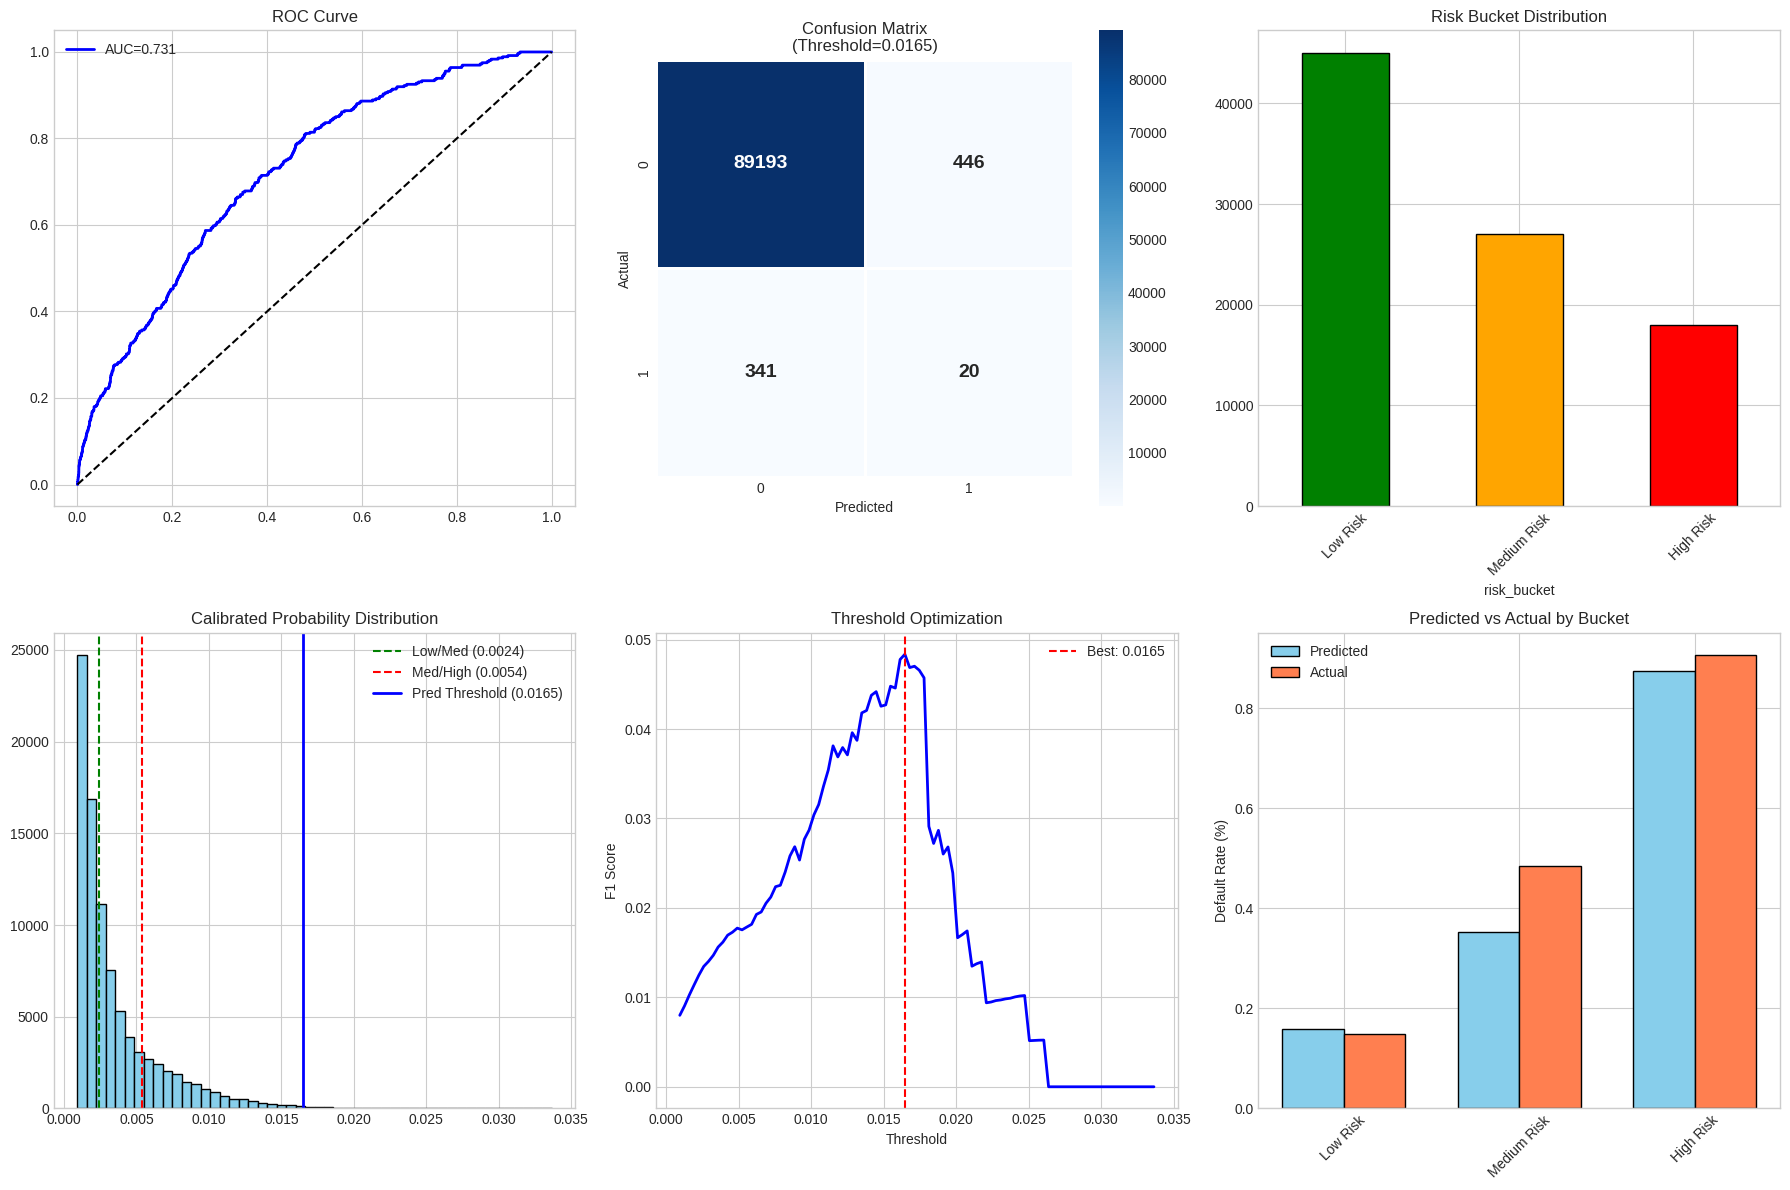

In [6]:
# ============================================================
# FIXED RANDOM FOREST - PROPER THRESHOLD HANDLING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, 
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve, brier_score_loss)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RANDOM FOREST - FIXED THRESHOLD VERSION")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("\n[1] LOADING DATA...")
FILE_PATH = '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv'

df = pd.read_csv(FILE_PATH, nrows=300000, low_memory=False)
print(f"✓ Loaded {len(df):,} rows")

df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
print(f"✓ Default rate: {df['default'].mean()*100:.2f}%")

# ============================================================
# STEP 2: PREPARE FEATURES
# ============================================================

print("\n[2] PREPARING FEATURES...")

features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
            'fico_range_low', 'grade', 'term', 'emp_length']

available = [f for f in features if f in df.columns]
print(f"✓ Features: {available}")

X = df[available].copy()
y = df['default'].copy()

# Encode
if 'grade' in X.columns:
    X['grade'] = X['grade'].map({'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}).fillna(4)
if 'term' in X.columns:
    X['term'] = X['term'].astype(str).str.extract('(\d+)').astype(float)
if 'emp_length' in X.columns:
    emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
               '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10,'n/a':0}
    X['emp_length'] = X['emp_length'].map(emp_map).fillna(0)

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"✓ Train: {len(X_train):,}, Test: {len(X_test):,}")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n[3] TRAINING RANDOM FOREST...")

preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), X.columns.tolist())
])

rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=30, max_depth=8, min_samples_split=300, min_samples_leaf=150,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
print("✓ Model trained")

# Get probabilities
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"\nProbability Statistics:")
print(f"  Min: {y_proba.min():.6f}")
print(f"  Max: {y_proba.max():.6f}")
print(f"  Mean: {y_proba.mean():.6f}")
print(f"  Median: {np.median(y_proba):.6f}")

# ============================================================
# STEP 4: FIND OPTIMAL THRESHOLD (FIXED!)
# ============================================================

print("\n[4] FINDING OPTIMAL THRESHOLD...")

# Method 1: Use percentile-based threshold (matches your risk buckets!)
p50_threshold = np.percentile(y_proba, 50)  # Median
p80_threshold = np.percentile(y_proba, 80)

print(f"  50th percentile (median): {p50_threshold:.6f}")
print(f"  80th percentile: {p80_threshold:.6f}")

# Method 2: Find threshold that maximizes F1
from sklearn.metrics import f1_score
thresholds = np.linspace(y_proba.min(), y_proba.max(), 100)
f1_scores = [f1_score(y_test, (y_proba > t).astype(int)) for t in thresholds]
best_f1_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"  Best F1 threshold: {best_f1_threshold:.6f} (F1={best_f1:.4f})")

# Use the F1-optimal threshold for predictions
y_pred = (y_proba > best_f1_threshold).astype(int)

# Calculate metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n✓ Performance with optimal threshold:")
print(f"  AUC: {auc:.4f}")
print(f"  Accuracy: {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall: {rec:.4f}")
print(f"  F1: {f1:.4f}")

# ============================================================
# STEP 5: CALIBRATE
# ============================================================

print("\n[5] CALIBRATING...")

sample_size = min(50000, len(X_train))
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_cal = X_train.iloc[idx]
y_cal = y_train.iloc[idx]

calibrated = CalibratedClassifierCV(rf, method='sigmoid', cv=3)
calibrated.fit(X_cal, y_cal)

y_proba_cal = calibrated.predict_proba(X_test)[:, 1]

# Recalculate optimal threshold for calibrated probabilities
thresholds_cal = np.linspace(y_proba_cal.min(), y_proba_cal.max(), 100)
f1_scores_cal = [f1_score(y_test, (y_proba_cal > t).astype(int)) for t in thresholds_cal]
best_thresh_cal = thresholds_cal[np.argmax(f1_scores_cal)]

y_pred_cal = (y_proba_cal > best_thresh_cal).astype(int)

brier = brier_score_loss(y_test, y_proba_cal)

print(f"  Calibrated best threshold: {best_thresh_cal:.6f}")
print(f"  Calibrated F1: {max(f1_scores_cal):.4f}")
print(f"  Brier Score: {brier:.4f}")

# ============================================================
# STEP 6: RISK BUCKETS (PERCENTILE-BASED)
# ============================================================

print("\n[6] CREATING RISK BUCKETS...")

# Use percentiles for risk bucketing (this is correct!)
p50 = np.percentile(y_proba_cal, 50)
p80 = np.percentile(y_proba_cal, 80)

def bucket(p):
    if p <= p50: return 'Low Risk'
    elif p <= p80: return 'Medium Risk'
    return 'High Risk'

results_df = pd.DataFrame({
    'loan_amnt': X_test['loan_amnt'].values,
    'prob_calibrated': y_proba_cal,
    'prob_original': y_proba,
    'predicted_default': y_pred_cal,
    'risk_bucket': [bucket(p) for p in y_proba_cal],
    'actual_default': y_test.values
})

results_df['expected_loss'] = results_df['prob_calibrated'] * 0.5 * results_df['loan_amnt']

print("\nRisk Distribution:")
for b in ['Low Risk', 'Medium Risk', 'High Risk']:
    subset = results_df[results_df['risk_bucket'] == b]
    pred_rate = subset['predicted_default'].mean()
    actual_rate = subset['actual_default'].mean()
    print(f"  {b}: {len(subset):,} ({len(subset)/len(results_df)*100:.1f}%) | "
          f"Pred: {pred_rate*100:.1f}% | Actual: {actual_rate*100:.1f}%")

el_rate = results_df['expected_loss'].sum() / results_df['loan_amnt'].sum() * 100
print(f"\nPortfolio EL Rate: {el_rate:.4f}%")

# ============================================================
# STEP 7: VISUALIZATIONS
# ============================================================

print("\n[7] PLOTTING...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. ROC Curve
ax1 = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_proba_cal)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC={auc:.3f}')
ax1.plot([0,1], [0,1], 'k--')
ax1.set_title('ROC Curve')
ax1.legend()

# 2. Confusion Matrix (FIXED!)
ax2 = axes[0, 1]
cm = confusion_matrix(y_test, y_pred_cal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, square=True, linewidths=2,
            annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title(f'Confusion Matrix\n(Threshold={best_thresh_cal:.4f})')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. Risk Buckets
ax3 = axes[0, 2]
risk_counts = results_df['risk_bucket'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk'])
colors = ['green', 'orange', 'red']
risk_counts.plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.set_title('Risk Bucket Distribution')
ax3.tick_params(axis='x', rotation=45)

# 4. Probability Distribution
ax4 = axes[1, 0]
results_df['prob_calibrated'].hist(bins=50, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(p50, color='green', linestyle='--', label=f'Low/Med ({p50:.4f})')
ax4.axvline(p80, color='red', linestyle='--', label=f'Med/High ({p80:.4f})')
ax4.axvline(best_thresh_cal, color='blue', linestyle='-', linewidth=2, label=f'Pred Threshold ({best_thresh_cal:.4f})')
ax4.set_title('Calibrated Probability Distribution')
ax4.legend()

# 5. Threshold vs F1
ax5 = axes[1, 1]
ax5.plot(thresholds_cal, f1_scores_cal, 'b-', linewidth=2)
ax5.axvline(best_thresh_cal, color='red', linestyle='--', label=f'Best: {best_thresh_cal:.4f}')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('F1 Score')
ax5.set_title('Threshold Optimization')
ax5.legend()

# 6. Predicted vs Actual by Bucket
ax6 = axes[1, 2]
bucket_stats = results_df.groupby('risk_bucket').agg({
    'prob_calibrated': 'mean',
    'actual_default': 'mean'
}).reindex(['Low Risk', 'Medium Risk', 'High Risk'])
x = np.arange(len(bucket_stats))
width = 0.35
ax6.bar(x - width/2, bucket_stats['prob_calibrated']*100, width, label='Predicted', color='skyblue', edgecolor='black')
ax6.bar(x + width/2, bucket_stats['actual_default']*100, width, label='Actual', color='coral', edgecolor='black')
ax6.set_xticks(x)
ax6.set_xticklabels(bucket_stats.index, rotation=45)
ax6.set_ylabel('Default Rate (%)')
ax6.set_title('Predicted vs Actual by Bucket')
ax6.legend()

plt.tight_layout()
plt.savefig('rf_fixed_output.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 8: SAVE
# ============================================================

print("\n[8] SAVING...")

results_df.to_csv('rf_fixed_results.csv', index=False)
joblib.dump(calibrated, 'rf_fixed_model.pkl')

print("\n" + "="*80)
print("✅ FIXED RANDOM FOREST COMPLETE!")
print(f"AUC: {auc:.4f} | F1: {f1:.4f} | EL Rate: {el_rate:.4f}%")
print(f"Optimal Threshold: {best_thresh_cal:.6f}")
print("Files: rf_fixed_results.csv, rf_fixed_model.pkl, rf_fixed_output.png")
print("="*80)